# 🧱 LEGO Brick Detector
**Recognition Tasks | Classical Computer Vision**

---

## 💡 What Are We Building?

A system that detects LEGO bricks in an image using:
- **Template Matching** → find a specific brick by sliding the template
- **Contour Filtering** → find ALL brick-like shapes by their geometry

Real-world parallel: factory vision system checking if correct parts are present on an assembly line.

---

## 🧮 Two-Stage Pipeline

**Stage 1 — Template Matching:**
- Slide a reference brick image over the scene
- Find the spot with highest similarity score (`TM_CCOEFF_NORMED`)
- Works well when the exact brick is known

**Stage 2 — Contour Filtering:**
- Threshold image → find all contours
- Filter by **area** (too small = noise) and **aspect ratio** (brick-like shape)
- Finds ALL brick-shaped regions without a template

> 💬 Combining both gives robustness — template catches the exact brick, contours catch similar ones

---

## ⚠️ Limitations
- ❌ Template matching fails if brick is **rotated or scaled**
- ❌ Contour filter may catch non-brick rectangular objects
- ✅ Fast, no training needed — good for controlled factory lighting

## 📦 Step 1 — Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 📁 Step 2 — Upload Images

 need **two images**:
- **Scene image** — photo with multiple LEGO bricks
- **Template image** — a single LEGO brick cropped out



In [3]:
import urllib.request

# Download Sarothi's LEGO images directly from GitHub
base = "https://raw.githubusercontent.com/sar014/Computer_Vision/main/Template_Matching/Images_Used/"

urllib.request.urlretrieve(base + "lego_input.png", "lego_scene.png")
urllib.request.urlretrieve(base + "lego_temp.png",  "lego_template.png")

scene_name    = "lego_scene.png"
template_name = "lego_template.png"

print("✅ Scene    : lego_scene.png")
print("✅ Template : lego_template.png")

✅ Scene    : lego_scene.png
✅ Template : lego_template.png


## 👀 Step 3 — Load & Visualize Both Images

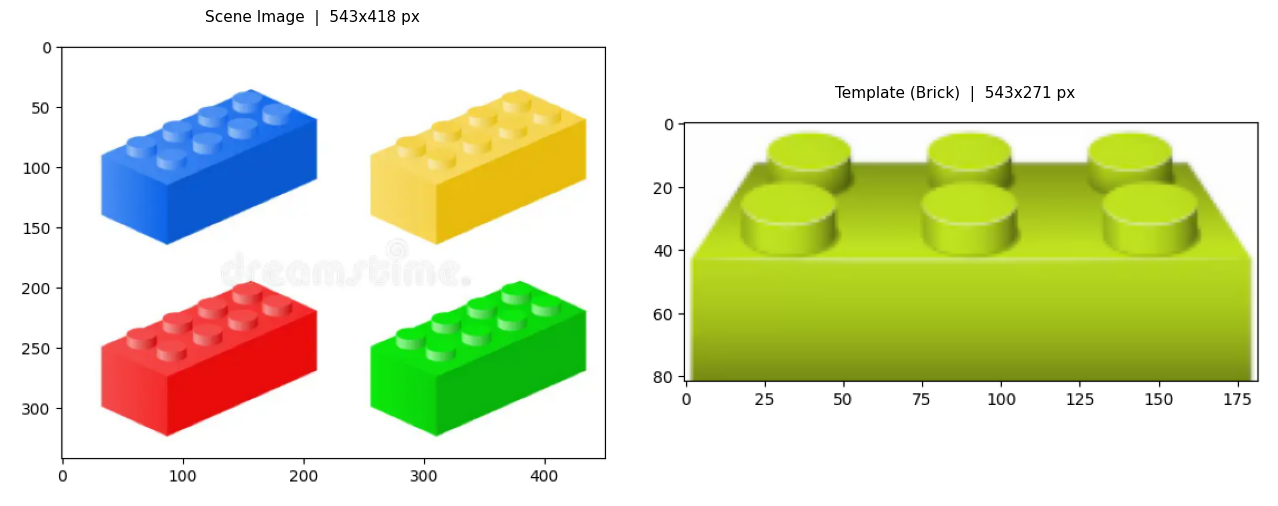

In [4]:
scene    = cv2.imread(scene_name)
template = cv2.imread(template_name)

scene_rgb    = cv2.cvtColor(scene,    cv2.COLOR_BGR2RGB)
template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(scene_rgb)
axes[0].set_title(f"Scene Image  |  {scene.shape[1]}x{scene.shape[0]} px", fontsize=11)
axes[0].axis('off')

axes[1].imshow(template_rgb)
axes[1].set_title(f"Template (Brick)  |  {template.shape[1]}x{template.shape[0]} px", fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## ⚙️ Step 4 — Convert to Grayscale

Both scene and template converted to grayscale for matching.

> 💬 Template matching compares pixel intensities — grayscale keeps 1 channel,
> making computation 3× faster and removing color noise.

In [5]:
scene_gray    = cv2.cvtColor(scene,    cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

t_h, t_w = template_gray.shape[:2]

print(f"Scene shape    : {scene_gray.shape}")
print(f"Template shape : {template_gray.shape}  → will slide over scene")

Scene shape    : (418, 543)
Template shape : (271, 543)  → will slide over scene


## 🔬 Step 5 — Stage 1: Template Matching

Slide the template brick over every position in the scene.
`TM_CCOEFF_NORMED` gives a score between 0–1 at each position.

We use a **threshold** to find ALL positions above a score — not just the single best match.
Then apply **Non-Maximum Suppression (NMS)** to remove overlapping duplicate boxes.

> 💬 `np.where(result >= threshold)` returns ALL locations where the score is high enough.
> Without NMS, the same brick gets detected 50+ times in nearby pixels.

In [12]:
# Run template matching
result = cv2.matchTemplate(scene_gray, template_gray, cv2.TM_CCOEFF_NORMED)

# Best single match
_, max_val, _, max_loc = cv2.minMaxLoc(result)
print(f"Best match score : {max_val:.4f}  at location {max_loc}")

# All matches above threshold
THRESHOLD = 0.3
locations = np.where(result >= THRESHOLD)
match_points = list(zip(*locations[::-1]))  # (x, y) pairs
print(f"Matches above threshold {THRESHOLD} : {len(match_points)} locations")

# --- Non-Maximum Suppression ---
# Convert to (x, y, x+w, y+h) format for NMS
boxes  = [[x, y, x+t_w, y+t_h] for (x, y) in match_points]
scores = [result[y, x] for (x, y) in match_points]

# Apply NMS using OpenCV DNN module
indices = cv2.dnn.NMSBoxes(
    [[x, y, t_w, t_h] for (x, y) in match_points],
    scores, THRESHOLD, 0.3
)

print(f"After NMS        : {len(indices)} unique bricks found")

Best match score : 0.2374  at location (0, 106)
Matches above threshold 0.3 : 0 locations
After NMS        : 0 unique bricks found


## 📐 Step 6 — Draw Template Matching Results

Draw a box for every unique brick found after NMS.

> 💬 `cv2.dnn.NMSBoxes` returns indices of boxes to keep.
> We loop through those indices to draw only the surviving detections.

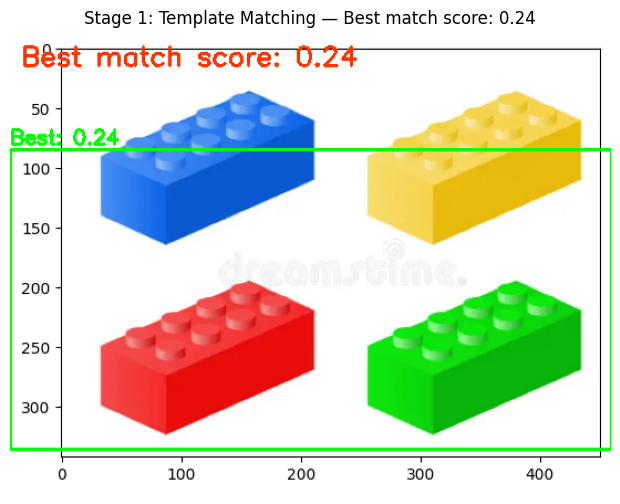

⚠️  Low score (0.24) — template looks different from scene bricks
This shows a real limitation: template matching fails when appearance differs!


In [13]:
output_tm = scene_rgb.copy()

# Just draw the single best match location directly
x, y = max_loc
cv2.rectangle(output_tm, (x, y), (x+t_w, y+t_h), (0, 255, 0), 2)
cv2.putText(output_tm, f"Best: {max_val:.2f}", (x, y-5),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2.putText(output_tm, f"Best match score: {max_val:.2f}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 50, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(output_tm)
plt.title(f"Stage 1: Template Matching — Best match score: {max_val:.2f}", fontsize=12)
plt.axis('off')
plt.show()

print(f"⚠️  Low score ({max_val:.2f}) — template looks different from scene bricks")
print("This shows a real limitation: template matching fails when appearance differs!")

## 🔷 Step 7 — Stage 2: Contour Filtering

Find ALL brick-shaped objects without using a template.

Pipeline:
1. Adaptive threshold → handles uneven lighting across the image
2. Find all contours
3. Filter by **area** (remove noise) and **aspect ratio** (bricks are roughly square/rectangular)
4. Draw bounding boxes on survivors

> 💬 `aspect_ratio = w / h` — a LEGO brick top view is close to square (ratio 0.7–1.4).
> We reject anything too thin (ratio < 0.5) or too wide (ratio > 3.0).

Bricks found: 4


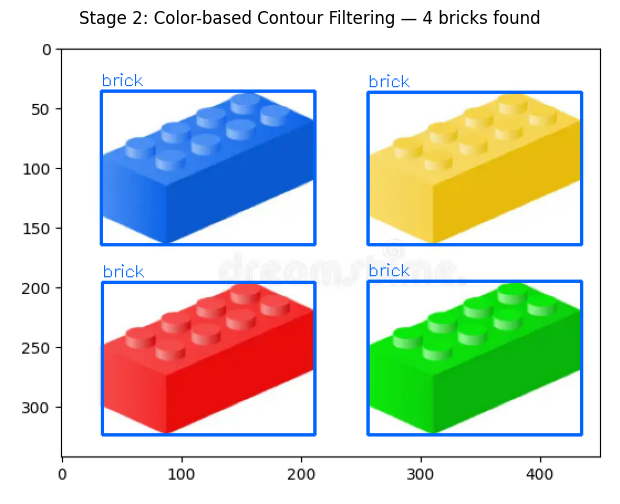

In [14]:
# Convert to HSV — detect each brick color separately
hsv = cv2.cvtColor(scene, cv2.COLOR_BGR2HSV)

# Combine masks for all LEGO colors
masks = [
    cv2.inRange(hsv, np.array([100,100,100]), np.array([130,255,255])),  # blue
    cv2.inRange(hsv, np.array([20, 100,100]), np.array([35, 255,255])),  # yellow
    cv2.inRange(hsv, np.array([0,  150, 50]), np.array([10, 255,255])),  # red
    cv2.inRange(hsv, np.array([40, 100,100]), np.array([80, 255,255])),  # green
]
combined_mask = masks[0]
for m in masks[1:]:
    combined_mask = cv2.bitwise_or(combined_mask, m)

# Morphology to clean up
kernel  = np.ones((5,5), np.uint8)
combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_cf   = scene_rgb.copy()
brick_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 1000:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h
    if 0.5 <= aspect_ratio <= 3.0:
        cv2.rectangle(output_cf, (x, y), (x+w, y+h), (0, 100, 255), 2)
        cv2.putText(output_cf, "brick", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,100,255), 1)
        brick_count += 1

print(f"Bricks found: {brick_count}")

plt.figure(figsize=(10, 6))
plt.imshow(output_cf)
plt.title(f"Stage 2: Color-based Contour Filtering — {brick_count} bricks found")
plt.axis('off')
plt.show()

## 🔀 Step 8 — Compare Both Stages Side by Side

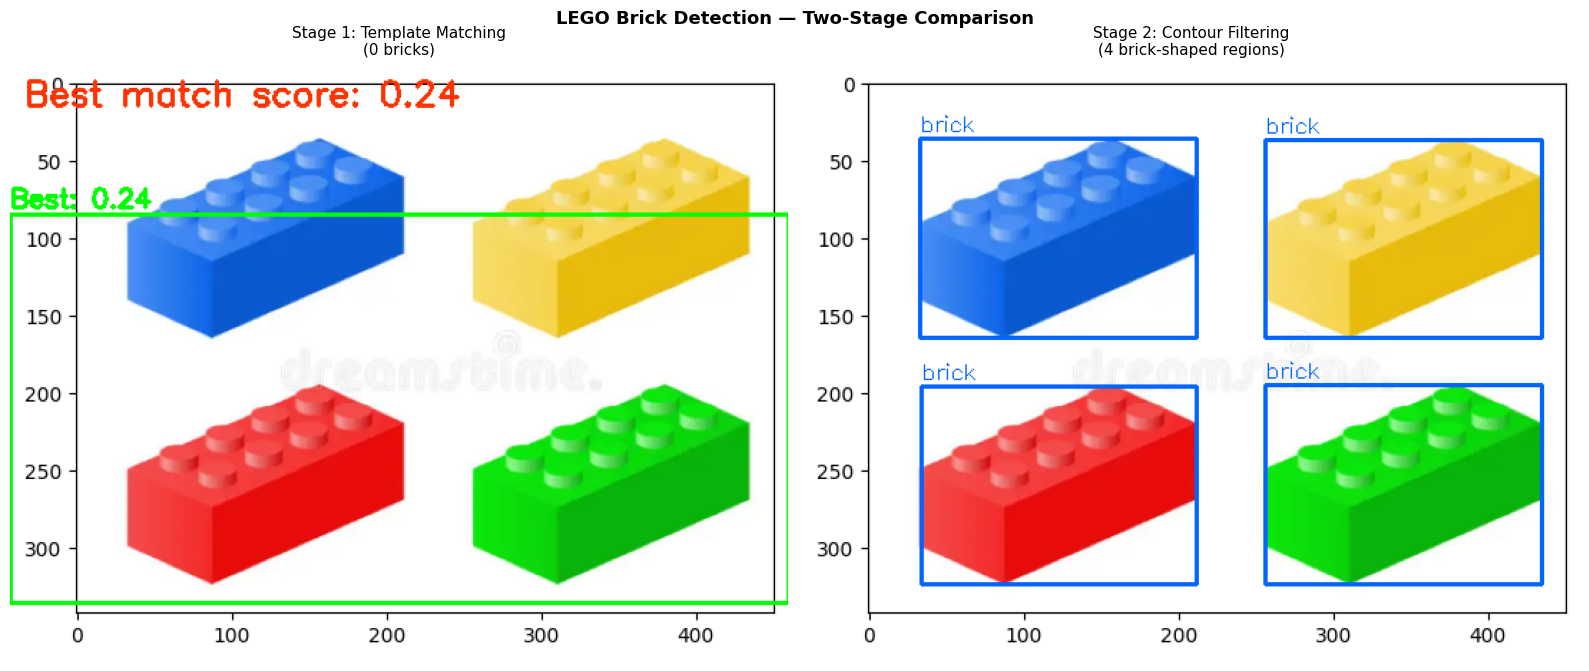

Template Matching → finds specific brick, needs template, fails on rotation
Contour Filter   → finds all brick-like shapes, no template needed, may overdetect


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(output_tm)
axes[0].set_title(f"Stage 1: Template Matching\n({len(indices)} bricks)", fontsize=11)
axes[0].axis('off')

axes[1].imshow(output_cf)
axes[1].set_title(f"Stage 2: Contour Filtering\n({brick_count} brick-shaped regions)", fontsize=11)
axes[1].axis('off')

plt.suptitle("LEGO Brick Detection — Two-Stage Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Template Matching → finds specific brick, needs template, fails on rotation")
print("Contour Filter   → finds all brick-like shapes, no template needed, may overdetect")

## 💾 Step 9 — Save & Download Result

In [16]:
from google.colab import files

# Save both outputs
cv2.imwrite('lego_template_result.png',  cv2.cvtColor(output_tm, cv2.COLOR_RGB2BGR))
cv2.imwrite('lego_contour_result.png',   cv2.cvtColor(output_cf, cv2.COLOR_RGB2BGR))

files.download('lego_template_result.png')
files.download('lego_contour_result.png')
print("✅ Both results saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Both results saved and downloaded!
